In [2]:
import numpy.random as random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [3]:
import scipy
import seaborn as sns

1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)

* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method

[ 2.  2.  9. 17. 16. 14. 11. 16.  8.  5.]
[np.float64(-0.2539041386890802), np.float64(-0.20199459497509564), np.float64(-0.15008505126111116), np.float64(-0.09817550754712666), np.float64(-0.046265963833142146), np.float64(0.005643579880842353), np.float64(0.057553123594826866), np.float64(0.10946266730881138), np.float64(0.16137221102279586), np.float64(0.21328175473678035)]
5.0092709683995045
128.1864609487435
99.99610878804113


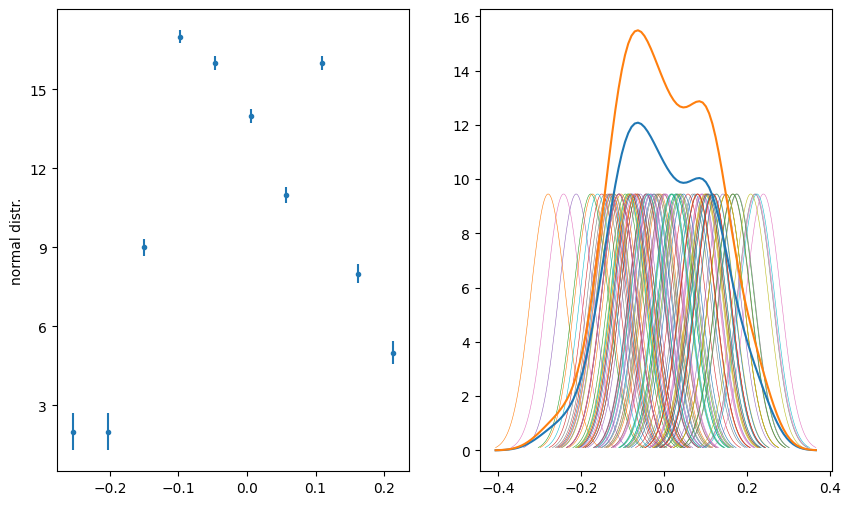

In [77]:
random.seed(123)
x=random.normal(loc=0.0,scale=0.1,size=100)
fig,ax= plt.subplots(figsize=(6, 6))
bins=int(np.sqrt(len(x)))
#ax.hist(x,bins=bins,histtype='step')
n,bins2,_=ax.hist(x,bins=bins)
plt.close()
bins3=[(bins2[i]+bins2[i+1])/2 for i in range(len(bins2)-1)]

fig,(ax2,ax3)= plt.subplots(nrows=1,ncols=2,figsize=(10, 6))
ax2.set_ylabel('normal distr.')
ax2.set_yticks(range(0,18,3))
# set proper ticks
# histogram as data points with errors
err_x=1/np.sqrt(n)
ax2.errorbar(x=bins3,y=n,yerr=err_x,fmt='.')

################################################
std_def=1.06*0.1*(100**(-0.2))
gaussians = [scipy.stats.norm(loc=i, scale=std_def) for i in x]

for i in gaussians:
    x_values = np.linspace(i.mean() - 3 * i.std(), i.mean() + 3 * i.std(), 100)
    pdf_values = i.pdf(x_values)
    ax3.plot(x_values,pdf_values, lw=0.4)
    
x_values = np.linspace(x.min() - 3 * std_def, x.max() + 3 * std_def, 100)
pdf_sum = np.sum([g.pdf(x_values) for g in gaussians], axis=0)

#integral = scipy.integrate.trapz(hist, bin_centers)

print(n)
print(bins3)
norm=scipy.integrate.trapezoid(x=bins3,y=n)
print(norm)
norm3=np.sum(pdf_sum)/100
print(norm3)
ax3.plot(x_values,(pdf_sum/norm3)*norm)
norm2=scipy.integrate.trapezoid(x=x_values,y=pdf_sum)
print(norm2)
pdf_sum=(pdf_sum/norm2)*norm
ax3.plot(x_values,pdf_sum)

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [33]:
def gaussian(mean,std,n,typedata):
    z_ofx=random.normal(loc=mean,scale=std,size=n)
    z_ofy=random.normal(loc=mean,scale=std,size=n)
    return pd.DataFrame({
        'x': z_ofx,
        'y': z_ofy,
        'cat':typedata
    })
    
def gaussians2(mean1,mean2,std1,std2,n,type1,type2):
    gau1=gaussian(mean1,std1,n,type1)
    gau2=gaussian(mean2,std2,n,type2)
    return pd.concat([gau1,gau2])
    

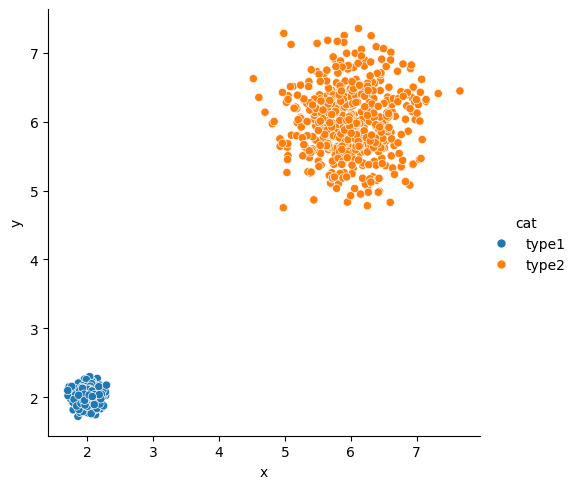

In [34]:
plot1=gaussians2(2,6,0.1,0.5,500,'type1','type2')
sns.relplot(x='x',y='y',hue='cat',data=plot1)

--2024-12-14 19:42:36--  https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35 [following]
--2024-12-14 19:42:38--  https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3f64ab0a95378074aec21cd21c.dl.dropboxusercontent.com/cd/0/inline/CgSbdN-bJIuxXhqTv24yFCiB6uel0EmHYWZH5AlIkt9chdMJrJPYYRIzvkXqSFqdAkLQaROaHFul4ymzh_6-Mb9rpwWnb6x_N_-6jv3WQeR0W4Kg6YpXyOOvLShnGyXoFag/file# [following]
--2024-12-14 19:42:38--  https://uc3f64ab0a95378074aec21cd21c.

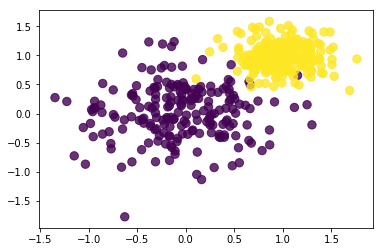

In [1]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```


In [3]:
!wget 'https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy'

--2024-12-08 10:35:03--  https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt [following]
--2024-12-08 10:35:04--  https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uca9f075889c147f19eb286e0f12.dl.dropboxusercontent.com/cd/0/inline/Cf38JW8evqnP9ozJFV1Sc7Jq9qzDfhcM9uaHmhQMcleEpdv4oF--ABR6VJhZ8o-Kp2ut9C44f4ZuugbNCm576B-5Wd3OlnDj5d1Tv8r5UkqG1VDPVhYgVu9RIJbnM2uvWsg/file# [following]
--2024-12-08 10:35:05--  https://uca9f075889c147f19eb286e0f12.dl.dropboxusercontent.com/cd/0/inline/Cf38

Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)


In [4]:
data = np.load('residuals_261.npy', allow_pickle=True).item()
df = pd.DataFrame(data)
df.describe()

,residuals,distances
count,11131.000000,11131.000000
mean,-0.616477,9.771465
std,4.163705,5.877819
min,-160.850000,0.000000
25%,-0.330000,4.400000
50%,-0.110000,9.700000
75%,0.060000,14.900000
max,11.320000,24.900000


* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot


0.0032597701220305835 -0.15432816763069473


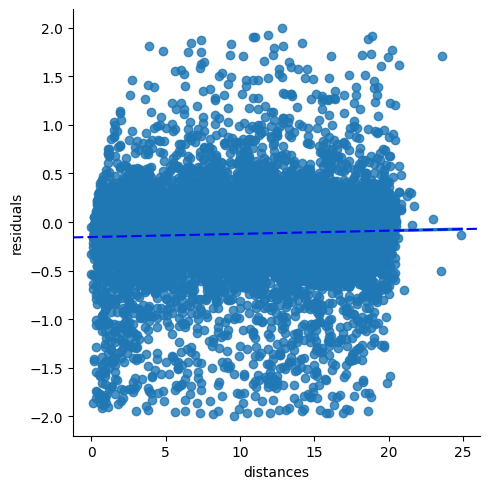

In [5]:
df=df[abs(df['residuals'])<2]
df.describe()
#scipy.stats.linregress?
results=scipy.stats.linregress(df['distances'],df['residuals'])
print(results.slope, results.intercept)
#sns.regression??
g = sns.lmplot(x='distances',y='residuals',data=df)
g.ax.axline(xy1=(0, results.intercept), slope=results.slope, color="b", dashes=(5, 2))


* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [6]:
#x array of bin with distance
#y residuals binned by distance

n=int(np.sqrt(len(df)))

print('n: ',n)     #n=102

wt=20/n
print(wt)
x=np.arange((0+wt/2),(20+wt/2),step=wt)
print('x: ',x)
print('length of x: ',len(x))    #should be n!!!!!

n:  102
0.19607843137254902
x:  [ 0.09803922  0.29411765  0.49019608  0.68627451  0.88235294  1.07843137
  1.2745098   1.47058824  1.66666667  1.8627451   2.05882353  2.25490196
  2.45098039  2.64705882  2.84313725  3.03921569  3.23529412  3.43137255
  3.62745098  3.82352941  4.01960784  4.21568627  4.41176471  4.60784314
  4.80392157  5.          5.19607843  5.39215686  5.58823529  5.78431373
  5.98039216  6.17647059  6.37254902  6.56862745  6.76470588  6.96078431
  7.15686275  7.35294118  7.54901961  7.74509804  7.94117647  8.1372549
  8.33333333  8.52941176  8.7254902   8.92156863  9.11764706  9.31372549
  9.50980392  9.70588235  9.90196078 10.09803922 10.29411765 10.49019608
 10.68627451 10.88235294 11.07843137 11.2745098  11.47058824 11.66666667
 11.8627451  12.05882353 12.25490196 12.45098039 12.64705882 12.84313725
 13.03921569 13.23529412 13.43137255 13.62745098 13.82352941 14.01960784
 14.21568627 14.41176471 14.60784314 14.80392157 15.         15.19607843
 15.39215686 15.5882

[0.0, 0.19607843137254902, 0.39215686274509803, 0.5882352941176471, 0.7843137254901962, 0.9803921568627452, 1.1764705882352944, 1.3725490196078436, 1.5686274509803926, 1.7647058823529416, 1.9607843137254906, 2.1568627450980395, 2.3529411764705888, 2.549019607843138, 2.7450980392156867, 2.941176470588236, 3.1372549019607847, 3.333333333333334, 3.529411764705883, 3.725490196078432, 3.921568627450981, 4.117647058823529, 4.313725490196078, 4.509803921568627, 4.705882352941177, 4.901960784313726, 5.098039215686274, 5.294117647058823, 5.490196078431373, 5.686274509803922, 5.882352941176471, 6.078431372549019, 6.2745098039215685, 6.470588235294118, 6.666666666666667, 6.862745098039216, 7.0588235294117645, 7.254901960784314, 7.450980392156863, 7.647058823529412, 7.843137254901961, 8.03921568627451, 8.23529411764706, 8.431372549019608, 8.627450980392156, 8.823529411764707, 9.019607843137255, 9.215686274509805, 9.411764705882353, 9.607843137254903, 9.803921568627452, 10.0, 10.19607843137255, 10.

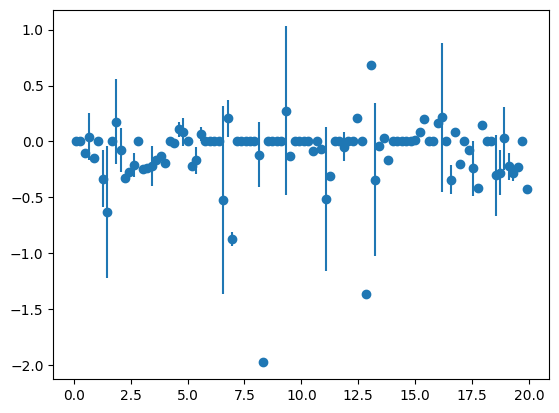

In [23]:
y=[]
x_bin_max=[0.]
x_bin_max.extend((x+wt/2).tolist())
x_bin_max[-1]=26.0 #I'm making it include also all points >20
print(x_bin_max)
print(len(x_bin_max))

print(range(1,n))
print(n)


y=[]
yerr=[]
for j in range(n):
    yi=[]
    for i in range(1,n):
        if ( (float(df['distances'].iloc[i-1])>=x_bin_max[j-1]) & (float(df['distances'].iloc[i-1])<x_bin_max[j]) ):
            yi.append(df['residuals'].iloc[i-1])
        
    y.append(np.mean(yi) if yi else 0.0)
    yerr.append(np.std(yi) if yi else 0.0)
    
print(len(y))        
print(len(x))
#n number of bins, x has the mean value for each bin
print(x[-1])
plt.scatter(x,y)
plt.errorbar(x,y,yerr=yerr,fmt='None') 

